# HVFHV — Burden Ranking & Heterogeneity (Goal 1)

**Goal 1 (see `docs/burden_analysis_and_modeling_plan.md`): which HVFHV zone-sides bear the CBD fee most, and does the burden vary by geography, trip length, or airport status?**

`DS_z` = median CBD fee as a share of the regulated base cost (pre-tip passenger cost minus the fee), per zone×direction among 2025 charged HVFHV trips, with a **$1 base-cost floor**. The base cost is rounded to cents **before** the floor so that floating-point near-zero denominators (summing several double-precision fee components can leave ~1e-16 residuals) cannot dominate the mean. Unlike Yellow (metered `total_amount`), HVFHV cost is reconstructed from TLC fee components, and there is no Flex/card-cash split — all HVFHV trips enter.

This is the burden deliverable; the *volume-effect* question (Goal 2) lives in `hvfhv_model1_model2.ipynb`. Structure and口径 mirror `yellow_burden_ranking_and_heterogeneity.ipynb` so the two services compare. Result tables → `results/burden_analysis/tables/`, figures → `results/burden_analysis/figures/`.

In [1]:
import numpy as np, pandas as pd, duckdb
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO/'data'/'processed').exists() and REPO != REPO.parent: REPO = REPO.parent
DS  = REPO/'data'/'processed'/'disruption_score'
FIG = REPO/'results'/'figures'; TAB = REPO/'results'/'tables'
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
HVFHV_GLOB = (REPO/'data'/'processed'/'00_standardized_trips'/'hvfhv').as_posix()+'/*/*.parquet'
AIRPORT_ZONES = {132, 138}   # JFK, LaGuardia (Newark zone 1 is EWR/NJ, no NYC airport fee -> 'ewr')

dv = pd.read_csv(DS/'hvfhv_ds_z_vs_volume_change.csv')
dv['zone_type'] = np.select(
    [dv.zone.isin(AIRPORT_ZONES), dv.Borough=='EWR', dv.Borough=='Manhattan'],
    ['airport', 'ewr', 'manhattan'], default='outer')
m1 = dv[(~dv.low_n_flag) & dv.pct_volume_change.notna()].copy()   # HVFHV convention: low_n_flag already encodes N<100
print(f'usable zone x direction units: {len(m1)}  |  by type: {m1.zone_type.value_counts().to_dict()}')

usable zone x direction units: 519  |  by type: {'outer': 382, 'manhattan': 132, 'airport': 4, 'ewr': 1}


## 1. Burden ranking — top zone-sides by `DS_z`

The headline Goal-1 output: which HVFHV zone-sides carry the largest fee relative to fare. The overall top list is saved to `results/burden_analysis/tables/hvfhv_top_ds_zones.csv`; pickup-only and dropoff-only lists are saved to `results/burden_analysis/tables/hvfhv_top_ds_zones_pickup.csv` and `results/burden_analysis/tables/hvfhv_top_ds_zones_dropoff.csv`. The figure shows the overall top list.


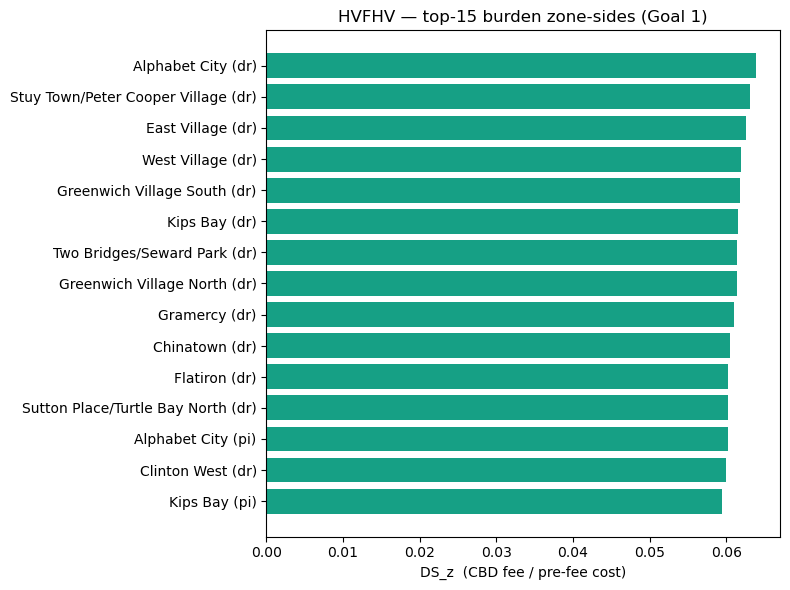

Overall top 15:
                     zone_name direction   DS_z  DS_z_median    N_z
                 Alphabet City   dropoff 0.0638       0.0593 239356
Stuy Town/Peter Cooper Village   dropoff 0.0631       0.0594 160441
                  East Village   dropoff 0.0625       0.0578 983593
                  West Village   dropoff 0.0619       0.0588 742528
       Greenwich Village South   dropoff 0.0617       0.0576 526218
                      Kips Bay   dropoff 0.0615       0.0569 499679
       Two Bridges/Seward Park   dropoff 0.0614       0.0566 353805
       Greenwich Village North   dropoff 0.0614       0.0571 492654
                      Gramercy   dropoff 0.0610       0.0566 628489
                     Chinatown   dropoff 0.0605       0.0550 212931
                      Flatiron   dropoff 0.0602       0.0565 545771
 Sutton Place/Turtle Bay North   dropoff 0.0602       0.0557 427328
                 Alphabet City    pickup 0.0602       0.0562 284803
                  Clinton West  

In [2]:
rank_cols = ['zone','direction','zone_name','Borough','DS_z','DS_z_median','N_z','DS_z_rank']

rank = m1.sort_values('DS_z', ascending=False).head(15)
rank[rank_cols].to_csv(TAB/'hvfhv_top_ds_zones.csv', index=False)

rank_pickup = m1[m1.direction.eq('pickup')].sort_values('DS_z', ascending=False).head(15)
rank_dropoff = m1[m1.direction.eq('dropoff')].sort_values('DS_z', ascending=False).head(15)
rank_pickup[rank_cols].to_csv(TAB/'hvfhv_top_ds_zones_pickup.csv', index=False)
rank_dropoff[rank_cols].to_csv(TAB/'hvfhv_top_ds_zones_dropoff.csv', index=False)

labels = [f'{r.zone_name} ({r.direction[:2]})' for r in rank.itertuples()]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(labels[::-1], rank['DS_z'].values[::-1], color='#16a085')
ax.set_xlabel('DS_z  (CBD fee / pre-fee cost)'); ax.set_title('HVFHV — top-15 burden zone-sides (Goal 1)')
plt.tight_layout(); fig.savefig(FIG/'hvfhv_top_ds_zones.png', dpi=150, bbox_inches='tight'); plt.show()

print('Overall top 15:')
print(rank[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))
print('\nPickup-only top 15:')
print(rank_pickup[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))
print('\nDropoff-only top 15:')
print(rank_dropoff[['zone_name','direction','DS_z','DS_z_median','N_z']].round(4).to_string(index=False))


## 2. Ranking robustness — stable to the base-cost floor?

Rank stability and top-zone overlap vs the primary \$1-floor definition (from the DS_z pipeline outputs).

In [3]:
rankstab = pd.read_csv(DS/'hvfhv_ds_rank_stability.csv')
overlap  = pd.read_csv(DS/'hvfhv_ds_top_zone_overlap.csv')
print('Rank stability vs the $1 primary (mean, all directions):')
print(rankstab[(rankstab.aggregation_method=='mean') & (rankstab.direction=='all')]
      [['denominator_floor','spearman_rank_corr_vs_primary','mean_abs_rank_delta','max_abs_rank_delta']].round(3).to_string(index=False))
print('\nTop-10/20 zone overlap vs $1 primary (mean, share):')
print(overlap[overlap.aggregation_method=='mean'].groupby(['denominator_floor','top_n']).overlap_share.mean().round(3).to_string())

Rank stability vs the $1 primary (mean, all directions):
 denominator_floor  spearman_rank_corr_vs_primary  mean_abs_rank_delta  max_abs_rank_delta
               0.5                            1.0                0.004                   1
               1.0                            1.0                0.000                   0
               2.0                            1.0                0.015                   4
               5.0                            1.0                0.065                   9

Top-10/20 zone overlap vs $1 primary (mean, share):
denominator_floor  top_n
0.5                10       1.0
                   20       1.0
1.0                10       1.0
                   20       1.0
2.0                10       1.0
                   20       1.0
5.0                10       1.0
                   20       1.0


## 3. Heterogeneity — geography of burden

This section summarizes where HVFHV `DS_z` is highest across broad geographic strata. Output is a burden distribution table. Saved to `results/burden_analysis/tables/hvfhv_burden_by_borough.csv` and `results/burden_analysis/tables/hvfhv_burden_by_borough_direction.csv`. EWR is kept separate because Newark is not a NYC airport-fee zone.


In [4]:
burden_rows = []
for zt in ['manhattan', 'outer', 'airport', 'ewr']:
    sub = m1[m1.zone_type.eq(zt)].copy()
    if sub.empty:
        continue
    top = sub.sort_values('DS_z', ascending=False).iloc[0]
    burden_rows.append({
        'stratum': zt,
        'n_zone_dir': len(sub),
        'mean_DS_z': sub.DS_z.mean(),
        'median_DS_z': sub.DS_z.median(),
        'p25_DS_z': sub.DS_z.quantile(0.25),
        'p75_DS_z': sub.DS_z.quantile(0.75),
        'max_DS_z': sub.DS_z.max(),
        'top_zone': top.zone_name if pd.notna(top.zone_name) else f'zone {int(top.zone)}',
        'top_direction': top.direction,
    })

burden_geo = pd.DataFrame(burden_rows)
burden_geo.to_csv(TAB/'hvfhv_burden_by_borough.csv', index=False)
print('HVFHV DS_z by geographic stratum:')
print(burden_geo.round(4).to_string(index=False))

direction_geo = (m1.groupby(['zone_type', 'direction'], observed=True)
                 .agg(n_zone_dir=('DS_z', 'size'), median_DS_z=('DS_z', 'median'), mean_DS_z=('DS_z', 'mean'))
                 .reset_index())
direction_geo.to_csv(TAB/'hvfhv_burden_by_borough_direction.csv', index=False)
print('\nHVFHV DS_z by stratum and direction:')
print(direction_geo.round(4).to_string(index=False))


HVFHV DS_z by geographic stratum:
  stratum  n_zone_dir  mean_DS_z  median_DS_z  p25_DS_z  p75_DS_z  max_DS_z                    top_zone top_direction
manhattan         132     0.0496       0.0514    0.0435    0.0566    0.0638               Alphabet City       dropoff
    outer         382     0.0271       0.0255    0.0207    0.0330    0.0506 Downtown Brooklyn/MetroTech       dropoff
  airport           4     0.0176       0.0177    0.0147    0.0206    0.0210           LaGuardia Airport       dropoff
      ewr           1     0.0146       0.0146    0.0146    0.0146    0.0146              Newark Airport       dropoff

HVFHV DS_z by stratum and direction:
zone_type direction  n_zone_dir  median_DS_z  mean_DS_z
  airport   dropoff           2       0.0174     0.0174
  airport    pickup           2       0.0177     0.0177
      ewr   dropoff           1       0.0146     0.0146
manhattan   dropoff          66       0.0530     0.0510
manhattan    pickup          66       0.0496     0.0481
  

## 4. Heterogeneity — trip-length disaggregation

`DS_z` per zone×direction×length bucket, then within Manhattan. HVFHV charged-trip distance thresholds (p25 = 1.80 mi, p75 = 7.86 mi) define short / medium / long. Question: how much larger is the burden for short trips than for medium and long trips? Saved to `results/burden_analysis/tables/hvfhv_burden_by_trip_length.csv`.


In [5]:
P25, P75 = 1.80, 7.86
con = duckdb.connect(); con.execute('SET threads TO 1')
con.execute(f"""
CREATE OR REPLACE TABLE ds_by_len AS
WITH t AS (
  SELECT PULocationID, DOLocationID,
    CASE WHEN trip_distance_miles < {P25} THEN 'short'
         WHEN trip_distance_miles <= {P75} THEN 'medium' ELSE 'long' END AS trip_length,
    cbd_congestion_fee / GREATEST(ROUND(passenger_cost_pretip - cbd_congestion_fee, 2), 1.00) AS fee_burden
  FROM read_parquet('{HVFHV_GLOB}')
  WHERE year=2025 AND charged_cbd_flag AND cbd_congestion_fee>0
    AND ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) > 0
),
pu AS (SELECT PULocationID AS zone,'pickup' AS direction,trip_length,MEDIAN(fee_burden) AS DS_z_med,COUNT(*) AS n FROM t GROUP BY PULocationID,trip_length),
do_ AS (SELECT DOLocationID AS zone,'dropoff' AS direction,trip_length,MEDIAN(fee_burden) AS DS_z_med,COUNT(*) AS n FROM t GROUP BY DOLocationID,trip_length)
SELECT * FROM pu UNION ALL SELECT * FROM do_
""")
bylen = con.execute('SELECT * FROM ds_by_len').df()
ml = bylen.merge(dv[['zone','direction','Borough','low_n_flag']], on=['zone','direction'])
ml = ml[(ml.Borough=='Manhattan') & (ml.zone!=194) & (~ml.low_n_flag) & (ml.n>=30)]
out = []
for lg in ['short','medium','long']:
    s = ml[ml.trip_length==lg].copy()
    s['q'] = pd.qcut(s.DS_z_med, 4, labels=[1,2,3,4])
    g = s.groupby('q', observed=True).agg(
        avg_DS_z=('DS_z_med','mean'),
        median_DS_z=('DS_z_med','median'),
        n_zone_dir=('DS_z_med','size'),
        median_trip_count=('n','median'),
    ).reset_index()
    g.insert(0,'trip_length',lg); out.append(g)
res = pd.concat(out, ignore_index=True)
res.to_csv(TAB/'hvfhv_burden_by_trip_length.csv', index=False)
print('Within-Manhattan, DS_z quartiles by trip length:')
print(res.round(4).to_string(index=False))
print('\nBurden by length (Q1 vs Q4):')
for lg in ['short','medium','long']:
    s = res[res.trip_length==lg]
    print(f'  {lg:7s}: DS_z Q1={s[s.q==1].avg_DS_z.iloc[0]:.1%} -> Q4={s[s.q==4].avg_DS_z.iloc[0]:.1%}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Within-Manhattan, DS_z quartiles by trip length:
trip_length q  avg_DS_z  median_DS_z  n_zone_dir  median_trip_count
      short 1    0.0716       0.0718          25           208753.0
      short 2    0.0783       0.0788          24           173946.0
      short 3    0.0810       0.0811          25           225875.0
      short 4    0.0856       0.0851          24            85083.5
     medium 1    0.0413       0.0413          32           184585.5
     medium 2    0.0438       0.0438          31           173793.0
     medium 3    0.0460       0.0458          32           251201.5
     medium 4    0.0508       0.0501          30           234664.0
       long 1    0.0186       0.0186          33            94144.0
       long 2    0.0223       0.0225          33            83831.0
       long 3    0.0253       0.0252          31            34393.0
       long 4    0.0311       0.0309          33            19267.0

Burden by length (Q1 vs Q4):
  short  : DS_z Q1=7.2% -> Q4=8.6%
  

## 5. Heterogeneity — airport vs non-airport burden

HVFHV trips carry an `airport_fee`; airport trips (JFK/LaGuardia) are long, high-fare hauls, so the flat CBD fee is a small share of cost — and airports sit outside the CRZ, so they are charged less often. At the zone level airports are only ~3 zones (n too small to correlate), but the trip-level comparison is clear. Saved to `results/burden_analysis/tables/hvfhv_airport_vs_nonairport_burden.csv`.

In [6]:
ap = con.execute(f"""
SELECT (airport_fee > 0) AS is_airport,
  COUNT(*) AS n,
  ROUND(MEDIAN(passenger_cost_pretip),2) AS med_cost,
  ROUND(MEDIAN(trip_distance_miles),2) AS med_dist,
  ROUND(AVG(charged_cbd_flag::INT),4) AS charged_share,
  ROUND(MEDIAN(CASE WHEN charged_cbd_flag THEN cbd_congestion_fee/GREATEST(ROUND(passenger_cost_pretip-cbd_congestion_fee,2),1.00) END),4) AS med_burden_charged
FROM read_parquet('{HVFHV_GLOB}')
WHERE year=2025
GROUP BY (airport_fee > 0) ORDER BY is_airport
""").df()
ap['group'] = np.where(ap.is_airport, 'airport', 'non-airport')
ap = ap[['group','n','med_cost','med_dist','charged_share','med_burden_charged']]
ap.to_csv(TAB/'hvfhv_airport_vs_nonairport_burden.csv', index=False)
print('HVFHV airport vs non-airport (2025):'); print(ap.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HVFHV airport vs non-airport (2025):
      group        n  med_cost  med_dist  charged_share  med_burden_charged
non-airport 91938311     22.01      2.67         0.3391              0.0467
    airport  8565151     72.43     11.55         0.4134              0.0169


## 6. Burden map — `DS_z` choropleth

Zone-level `DS_z` (mean of pickup + dropoff, stable units) on the NYC TLC taxi-zone geometry (`data/geo/taxi_zones/`, projected NY State Plane). Saved to `results/burden_analysis/figures/hvfhv_dsz_choropleth.png`.

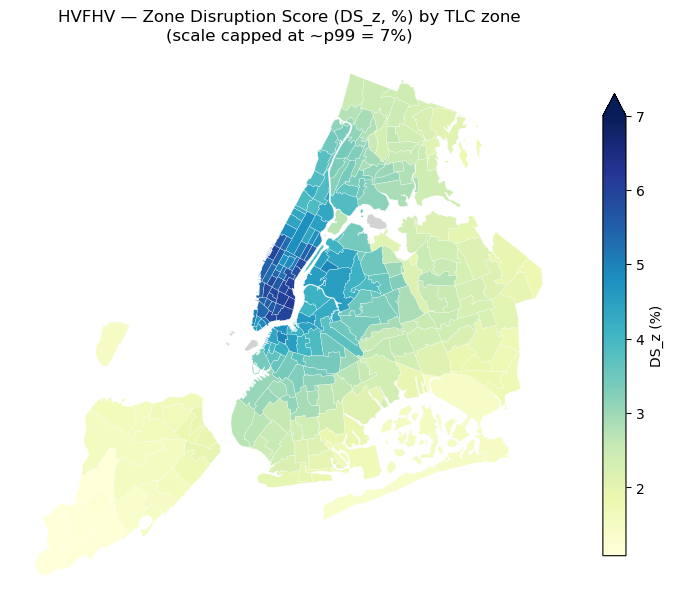

choropleth: 260 zones; range 0.011-0.062


In [7]:
import shapefile
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

zone_dsz = dv[~dv.low_n_flag].groupby('zone').DS_z.mean()
sf = shapefile.Reader(str(REPO/'data'/'geo'/'taxi_zones'/'taxi_zones.shp'))
patches, vals = [], []
for rec, shp in zip(sf.records(), sf.shapes()):
    v = zone_dsz.get(rec['LocationID'], np.nan)
    parts = list(shp.parts) + [len(shp.points)]
    for i in range(len(parts)-1):
        patches.append(Polygon(shp.points[parts[i]:parts[i+1]], closed=True)); vals.append(v)
vals = np.array(vals, float) * 100
cap = round(float(np.nanpercentile(list(zone_dsz*100), 99)) + 0.5)
cmap = plt.cm.YlGnBu.copy(); cmap.set_bad('lightgrey')
fig, ax = plt.subplots(figsize=(9, 10))
pc = PatchCollection(patches, cmap=cmap, edgecolor='white', linewidth=0.2)
pc.set_array(np.ma.masked_invalid(vals)); pc.set_clim(np.nanmin(vals), cap)
ax.add_collection(pc); ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'HVFHV — Zone Disruption Score (DS_z, %) by TLC zone\n(scale capped at ~p99 = {cap}%)')
cb = fig.colorbar(pc, ax=ax, shrink=0.6, extend='max'); cb.set_label('DS_z (%)')
fig.savefig(FIG/'hvfhv_dsz_choropleth.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'choropleth: {zone_dsz.notna().sum()} zones; range {zone_dsz.min():.3f}-{zone_dsz.max():.3f}')

## 7. Summary

**Burden ranking (Goal 1) — solid and robust.** Top burden zone-sides are concentrated in the dense Manhattan core (Alphabet City, Stuy Town, East Village, West Village, Greenwich Village, Kips Bay...), with `DS_z` around 6%. Pickup-only and dropoff-only rankings are reported separately, and the ranking is invariant to the base-cost floor: Spearman rank correlation versus the $1 primary is 1.00 across $0.50-$5, with 100% top-10/20 overlap at every floor.

**Burden is strongly regressive in trip length; airport trips bear less.** Within Manhattan, `DS_z` is highest for short trips, lower for medium trips, and lowest for long trips. Airport trips (JFK/LaGuardia; median fare $72.43, 11.5 mi) bear only **1.69%** burden versus **4.67%** for non-airport trips.

**Geography matters for burden.** The burden ranking is concentrated in Manhattan core zones. Outer-borough and airport/EWR zone-directions have lower measured `DS_z` because trips are usually longer or higher-cost, so the flat $1.50 fee is a smaller share of the pre-fee cost. The choropleth shows the same spatial pattern.

**Net:** the Goal-1 burden ranking is stable and interpretable, and HVFHV burden clearly varies by geography, trip length, and airport status.
